# XG Boosting

A subscription-based digital service company is facing customer churn, where users cancel their subscriptions after a few months.

- Key challenges:
    - Customer behavior patterns are complex and non-linear
    - Some customers leave suddenly despite appearing loyal
    - A single model fails to capture small but important signals
    - Business wants a high-performance and scalable solution


- The company already tried:
    - Logistic Regression
    - Decision Tree
    - Random Forest

    …but results are not satisfactory.
 

## Tasks:

1. Load the dataset and study customer attributes such as:
    - Tenure
    - Monthly charges
    - Contract type
    - Payment method

2. Identify the target variable and 
explain its business meaning.
Build a baseline classification model using a tree-based approach.

3. Evaluate its performance using:
    - Accuracy
    - Confusion Matrix
    - Recall for churn customers
 
4. Build an ensemble model that improves predictions iteratively.

5. Train the model using historical customer data.

6. Observe how the model:
    - Focuses more on previously misclassified customers
    - Learns complex patterns gradually
 
7. Evaluate the model using:
    - Accuracy
    - Precision
    - Recall
    - F1-Score

8. Compare the results with the baseline model.
 
9. Analyze the following:
    - How many churn customers were correctly identified?
    - How many loyal customers were wrongly flagged?

        Answer:
        - Is it better to wrongly flag a   loyal customer?
        Or miss a churn customer?

10. Which metric should the business prioritize and why?
 
11. Identify which customer features contribute most to churn prediction.

12. Explain how understanding feature importance helps business teams.
 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [1]:
import pandas as pd

df = pd.read_csv('Telco-Customer-Churn.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
X = df[['tenure', 'MonthlyCharges', 'Contract', 'PaymentMethod']]
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [13]:
X = pd.get_dummies(
    X,
    columns=['Contract', 'PaymentMethod'],
    drop_first=True
)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


In [17]:
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

base_model = DecisionTreeClassifier(max_depth=3)

classifier = XGBClassifier(n_estimators=100,learning_rate=0.1, max_depth=3, random_state=42, use_label_encoder=False,
    eval_metric='logloss')

In [18]:
classifier.fit(X_train, y_train)

c:\Users\rakes\anaconda31\envs\Himaenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:27:33] WARNING: C:\miniconda3\conda-bld\xgboost-split_1764761400759\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [19]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

y_pred = classifier.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred) )

Accuracy: 0.7991483321504613
Confusion Matrix:
 [[966  70]
 [213 160]]


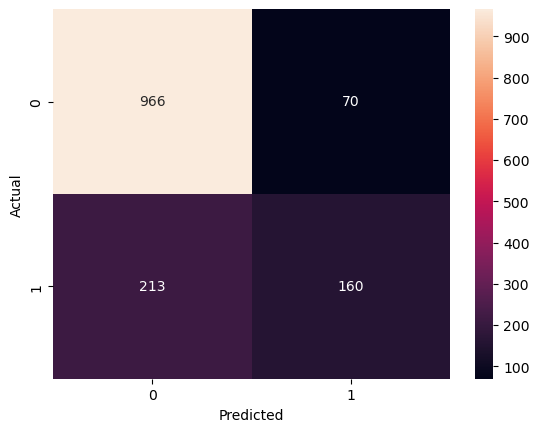

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()